## Set up Gurobipy
---

In [1]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 12.0.3
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: c:\Users\POM_Mobil_01\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.7
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 t

In [2]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [3]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## SALBP-2 model formulation
-----------------------------------------

When it comes to the "Simple Assembly Line Balancing Problem no. 2" there is a number of N operations with precedence relations to be performed on a fixed number of M stations. 
The operations are to be distributed among the stations in such a way that the cycle time is minimized. A simple result is illustrated in this precedence graph including station assignments.

<img src="pics/header.png" alt="Precedence graph" width="700">

### Objective function:

 0) The goal of the model is to minimize the cycle time:   $ \hspace{31mm} min \quad z = C $

### Constraints:

1) Assignment of  every  operation  only once: $\hspace{45mm} \sum_{k=1}^MS_{ik}=1  \hspace{39mm} \forall i=1,...,N $ 

2) Complying with the precedence relations: $\hspace{45mm} \sum_{k=1}^MS_{ik}\cdot k \leq \sum_{k=1}^MS_{jk}\cdot k \hspace{13mm} 
\forall(i,j) \in P$

3) Complying with the cycle time: $\hspace{63mm} \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{33mm} \forall k=1,...,M $

4) Binary decision variable: $\hspace{74mm} S_{ik} \in \{0,1\} \hspace{41mm} \forall i=1,...,N;k=1,...,M $

5) Non-negativity constraint: $\hspace{72mm} C \geq0$

---

#### Indices and sets
$i,j\in(1,..,N) \hspace{15mm}$  operations                      

$k\in(1,..,M) \hspace{17mm}$ stations                         

$(i,j)\in P \hspace{26mm}$ set of precedence relations     

#### Parameters
$t_i \hspace{40mm}$  Processing time of operation i 

#### Decision variables
$S_{ik} \hspace{38mm}$  Binary variable             

$C \hspace{41mm}$  Cycle time 

------------------------------------------------------------

### Create the model.
---

Initialize the model m with Gurobi as optimizer.

In [4]:
# Model
m = gp.Model("MILP")


# Surpress Output
m.setParam("OutputFlag", 0)
m.setParam("MIPgap", 0)

Set parameter Username
Set parameter LicenseID to value 2729909
Academic license - for non-commercial use only - expires 2026-10-30


### Case study data:
---

#### Number of stations: 6 

#### Operations:
| Operation | processing time| direct predecessors
|:-----------|:----------------|:------------------|
| 1 | 5.5 |   |  
| 2 | 7.4 |   | 
| 3 | 1.3 | 1   | 
| 4 | 9 | 1, 2   | 
| 5 | 2.6 | 3  | 
| 6 | 4.6 | 4, 7  | 
| 7 | 8 | 2  | 
| 8 | 4.5 | 5, 6  | 
| 9 | 3 | 7, 6  | 


### Sets and parameters
---

Insert the parameters: Operations i, Stations k, N, M and the PrecRelations as arrays.

In [5]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations = [1,2,3,4,5,6]

N = len(Operations)
M = len(Stations)

PrecRelations = [ [1, 3], [1, 4], [2, 4], [2, 7], [3, 5], [4, 6], [7, 6], [7, 9], [5, 8], [6, 8], [6, 9] ]

Insert the times needed for the single operations $t_i$ as an array.

In [6]:
t = [5.5, 7.4, 1.3, 9, 2.6, 4.6, 8, 4.5, 3]

### Decision variables
---

Define the decision variables including the non-negativity and binary constraints:

**4) Binary decision variable**: 
The binary decision variable $S_{ik}$ is 1 if an operation i is assigned to station k, otherwise 0.

In [7]:
S = m.addVars(N, M, vtype=GRB.BINARY, name="S");

**5)  Non-negativity constraint**:  The cycle time C can't be negative.

In [8]:
C = m.addVar(lb=0, name="C");

**5)  Auxiliary variable to break symmetry**:  Prefer assignment to lower station number in case of multiple solutions

In [9]:
symBreak = m.addVar(lb=0, name="symBreak");

### Objective function 
---

Define the objective value to minimize the cycle time.

Note: You can ignore the additional term "symBreak". We just want to make sure that everyone gets the same results when there is more than one possible solutions. 

*Be careful though! Because of this addition the optimal cycle time differs from the objective value.*

In [10]:
m.setObjective(C + symBreak, GRB.MINIMIZE)

### Constraints
---


**1) Assign every operation only once**: Each operation may be assigned only once. The sum of the number of assignments of each operation across all stations must therefore add up to one. 

$ \qquad \sum_{k=1}^{M} S_{ik} = 1 \hspace{40mm} \forall i=1,...,N$

In [11]:
m.addConstrs((quicksum(S[i, k] for k in range(M)) == 1 for i in range(N)), name="allOperCon");

**2) Complying the precedence relations**: An operation j may only begin when the predecessor operation i has been completed and can therefore not be processed on a station in front of i's processing station.

$ \qquad \sum_{k=1}^{M} S_{ik}\cdot k \leq \sum_{k=1}^{M} S_{jk}\cdot k \hspace{25mm}  \forall (i,j) \in P $

In [12]:
m.addConstrs((quicksum(S[i, k]*k for k in range(M)) <= quicksum(S[j, k]*k for k in range(M))
              for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="precRelCon");

**3) Complying the cycle time**:
The cycle time must be smaller than the sum of the processing times of all operations carried out on a station k.

$ \qquad  \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{34mm} \forall k=1,...,M $




In [13]:
m.addConstrs((quicksum(S[i, k]*t[i] for i in range(N)) <= C for k in range(M)), name="cycleTimeCon");

**4) Symmetry breaking constraint**

In [14]:
m.addConstr(symBreak >= quicksum(S[i, k]*k*(0.1**(i+1)) for k in range(M) for i in range(N)), name="symBreakCon");

### Solve and display results
---

Get the whole model m displayed.

In [15]:
m

<gurobi.Model Continuous instance MILP: 0 constrs, 0 vars, Parameter changes: MIPGap=0.0, Username=(user-defined), LicenseID=2729909, OutputFlag=0>

Run the model m.

In [16]:
# Solve
m.optimize()


### Get the results displayed.

Print out the objective value C as well as the termination status and the primal status.

In [17]:
# Print results
if m.status == GRB.OPTIMAL:
    print("Objective value: ", m.objVal)
    print("Cycle Time C: ", C.x)
    print("Solution:")
    for i in range(N):
        for k in range(M):
            if S[i, k].x > 0.5:
                print("Operation ", i+1, " is assigned to station ", k+1)
else:
    print("No solution found")

Objective value:  9.010244355
Cycle Time C:  9.0
Solution:
Operation  1  is assigned to station  1
Operation  2  is assigned to station  2
Operation  3  is assigned to station  1
Operation  4  is assigned to station  3
Operation  5  is assigned to station  5
Operation  6  is assigned to station  5
Operation  7  is assigned to station  4
Operation  8  is assigned to station  6
Operation  9  is assigned to station  6


Now get displayed where each operation is performed, there might be other solutions as well leading to the same objective function value.

Want to add a nice visualization?

# Model extension — Budget-constrained SALBP-2 for an automotive final-assembly line
-----------------------------------------

The original SALBP-2 model above stays **unchanged**. This section applies the *extended* model to an exemplary **automotive final-assembly segment** with nine operations (underbody screwing, chassis marriage, windshield, wiring, cockpit, seats, interior trim, HV battery, final inspection). Each station is equipped with **one of four resource types** — **human**, **cobot** (supervised 1 worker : 3 cobots), **industrial robot** (fenced, full speed) or **humanoid robot** — each with its own processing times, an **eligibility profile** (some operations cannot be done by some resources at all), and its own investment + operating cost. The total resource cost must respect a budget $B$; the objective remains to **minimise the cycle time $C$** (SALBP-2 — cost never enters the objective). Sweeping $B$ traces the **time–cost (Pareto) frontier**.

### Extended model formulation

**Additional sets & parameters**

$r\in\{\text{Human},\ \text{Cobot},\ \text{IndRobot},\ \text{Humanoid}\}\hspace{8mm}$ resource types

$t_{ir}\hspace{40mm}$ processing time of operation $i$ with resource $r$

$E_{ir}\in\{0,1\}\hspace{29mm}$ eligibility: 1 if resource $r$ is able to perform operation $i$

$H\hspace{43mm}$ planning horizon / utilisation (h / year)

$K_r=\text{invest}_r+\text{oper}_r\cdot H\hspace{18mm}$ total cost of resource $r$ over the horizon

$B\hspace{43mm}$ investment budget

**Additional decision variables**

$Y_{kr}\in\{0,1\}\hspace{32mm}$ 1 if station $k$ is equipped with resource $r$

$S_{ikr}\in\{0,1\}\hspace{31mm}$ 1 if operation $i$ runs at station $k$ using resource $r$

**Objective** (unchanged): $\hspace{20mm}\min\quad z=C$

**Constraints**

0) Assign every operation once: $\hspace{20mm}\sum_{k}\sum_{r}S_{ikr}=1\hspace{20mm}\forall i$

1) One resource per station: $\hspace{23mm}\sum_{r}Y_{kr}=1\hspace{27mm}\forall k$

2) Coupling task $\to$ equipped resource: $\hspace{6mm}S_{ikr}\le Y_{kr}\hspace{27mm}\forall i,k,r$

3) Eligibility: $\hspace{41mm}S_{ikr}\le E_{ir}\hspace{28mm}\forall i,k,r$

4) Cycle time (resource-dependent): $\hspace{10mm}\sum_{i}\sum_{r}S_{ikr}\,t_{ir}\le C\hspace{18mm}\forall k$

5) Precedence relations: $\hspace{27mm}\sum_{k}\sum_{r}S_{ikr}\,k\le\sum_{k}\sum_{r}S_{jkr}\,k\hspace{8mm}\forall(i,j)\in P$

6) Budget: $\hspace{47mm}\sum_{k}\sum_{r}K_r\,Y_{kr}\le B$

*Solution procedure:* among all cheapest-possible optima we prefer the **cheapest** one, so the model is solved in two stages — first minimise $C$, then, fixing $C$ at its optimum, minimise total resource cost. This makes the reported equipment mixes stable and Pareto-efficient.

---

### The example line — 9 operations of automotive final assembly
---
| Op | Operation | dominant complexity | expected fit |
|----|-----------|---------------------|--------------|
| 1 | Unterboden verschrauben (Hitzeschilde, Leitungen) | overhead, heavy, repetitive | Cobot / Humanoid |
| 2 | Fahrwerk & Räder montieren | high payload, repetitive | Humanoid / heavy robot |
| 3 | Windschutzscheibe kleben & setzen | precision (adhesive bead) + weight | Cobot |
| 4 | Kabelbaum verlegen & stecken | deformable, fine, high variance | Human |
| 5 | Cockpit / Armaturenbrett einbauen | bulky, tight reach | Humanoid |
| 6 | Sitze einbauen | heavy, ergonomically stressful | Robot (Humanoid / Cobot with lift) |
| 7 | Innenverkleidung & Clips | fiddly, deformable clips | Human |
| 8 | HV-Batterie anschließen & Flüssigkeiten | safety + precision | Cobot |
| 9 | Endkontrolle (Spaltmaße, Funktion) | cognition, judgement | Human |

Precedence: the underbody work (1) opens the segment; wiring (4) must precede the cockpit (5), which precedes interior trim (7), which precedes the seats (6); chassis (2), windshield (3), seats (6) and HV battery (8) must all be finished before the final inspection (9).

In [18]:
# The automotive final-assembly line -------------------------------------------
OpNames = ["Unterboden verschrauben",          # 1  overhead, heavy, repetitive
           "Fahrwerk & Räder montieren",       # 2  high payload
           "Windschutzscheibe kleben",         # 3  precision + weight
           "Kabelbaum verlegen & stecken",     # 4  deformable, fine
           "Cockpit / Armaturenbrett",         # 5  bulky, tight reach
           "Sitze einbauen",                   # 6  heavy, ergonomically stressful
           "Innenverkleidung & Clips",         # 7  fiddly, deformable
           "HV-Batterie anschließen",          # 8  safety + precision
           "Endkontrolle"]                     # 9  cognition, judgement
N_a = len(OpNames)          # 9 operations
M_a = 6                     # stations of the segment

# precedence relations [predecessor, successor]  (1-indexed)
Prec_a = [[1,2],[1,8],[1,3],[1,4],      # underbody first
          [4,5],[5,7],[7,6],            # wiring -> cockpit -> trim -> seats
          [2,9],[3,9],[6,9],[8,9]]      # everything before final inspection

# human base times [min] (MTM-style estimates for one vehicle)
t_h = [3.5, 5.0, 4.0, 5.5, 4.5, 4.0, 4.5, 3.0, 2.5]

print(f"{N_a} operations on {M_a} stations,  total human work content = {sum(t_h)} min")
for i, (nm, ti) in enumerate(zip(OpNames, t_h)):
    print(f"  {i+1}: {nm:32s} {ti} min")

9 operations on 6 stations,  total human work content = 36.5 min
  1: Unterboden verschrauben          3.5 min
  2: Fahrwerk & Räder montieren       5.0 min
  3: Windschutzscheibe kleben         4.0 min
  4: Kabelbaum verlegen & stecken     5.5 min
  5: Cockpit / Armaturenbrett         4.5 min
  6: Sitze einbauen                   4.0 min
  7: Innenverkleidung & Clips         4.5 min
  8: HV-Batterie anschließen          3.0 min
  9: Endkontrolle                     2.5 min


### Resource-dependent times & eligibility
---
The four resource types differ in *which* operations they can do at all and *how fast* they do them. The human base times are scaled with per-operation factors; a dash means the resource is **not eligible** for that operation. The factor pattern follows the task characteristics above and the HRC literature convention of deriving resource times from human times via multipliers (cf. Weckenborg et al. 2020: robot ≈ 2.0×, well-balanced collaboration ≈ 0.7× human time):

* **Human** — can do everything; benchmark (factor 1.0). Only resource for judgement-based inspection (9) and the deformable wiring (4) / clips (7).
* **Cobot** (supervised, 1 worker per 3 cobots) — good at steady precision work (adhesive bead 3, torque-controlled screwing 1, HV connectors 8), too weak for chassis/cockpit payloads, hopeless on deformable clips (1.7×).
* **Industrial robot** (fenced, full speed) — fastest where a rigid, fixtured, repetitive task allows it (chassis 2, seats 6, battery 8), **ineligible** everywhere the line-side situation prevents fencing or requires adaptivity.
* **Humanoid** — human-like reach and two-handed handling of bulky parts without fixtures: best-in-class on overhead work (1), chassis marriage (2), cockpit (5) and seats (6); slower than humans on fine manipulation (4, 7).

In [19]:
Resources = ["Mensch", "Cobot", "Industrieroboter", "Humanoid"]
R = len(Resources)

# time factor per (operation, resource); None = not eligible
F = [
    # Mensch  Cobot  IndRob  Humanoid
    [1.0,     0.85,  None,   0.75],   # 1 Unterboden: overhead -> no fencing under the moving body
    [1.0,     None,  0.75,   0.65],   # 2 Fahrwerk: payload beyond cobot class
    [1.0,     0.80,  None,   1.00],   # 3 Scheibe: adhesive bead needs force-controlled cooperation
    [1.0,     None,  None,   1.40],   # 4 Kabelbaum: deformable -> only human (humanoid slow)
    [1.0,     None,  None,   0.70],   # 5 Cockpit: tight reach inside body -> human-shaped only
    [1.0,     1.00,  0.80,   0.70],   # 6 Sitze: heavy; robot needs lift/fixture
    [1.0,     1.70,  None,   1.50],   # 7 Clips: dexterity -> robots much slower
    [1.0,     0.85,  0.95,   1.00],   # 8 HV-Batterie: repeat-accurate, no HV risk for workers
    [1.0,     None,  None,   None],   # 9 Endkontrolle: judgement -> human only
]

t_r  = [[(round(F[i][r] * t_h[i], 2) if F[i][r] is not None else None)
         for r in range(R)] for i in range(N_a)]
elig = [[F[i][r] is not None for r in range(R)] for i in range(N_a)]

df_times = pd.DataFrame([[t_r[i][r] if elig[i][r] else "—" for r in range(R)] for i in range(N_a)],
                        columns=Resources, index=[f"{i+1} {OpNames[i]}" for i in range(N_a)])
print("Processing times t(i,r) [min]   (— = resource not eligible):")
print(df_times.to_string())

Processing times t(i,r) [min]   (— = resource not eligible):
                                Mensch Cobot Industrieroboter Humanoid
1 Unterboden verschrauben          3.5  2.98                —     2.62
2 Fahrwerk & Räder montieren       5.0     —             3.75     3.25
3 Windschutzscheibe kleben         4.0   3.2                —      4.0
4 Kabelbaum verlegen & stecken     5.5     —                —      7.7
5 Cockpit / Armaturenbrett         4.5     —                —     3.15
6 Sitze einbauen                   4.0   4.0              3.2      2.8
7 Innenverkleidung & Clips         4.5  7.65                —     6.75
8 HV-Batterie anschließen          3.0  2.55             2.85      3.0
9 Endkontrolle                     2.5     —                —        —


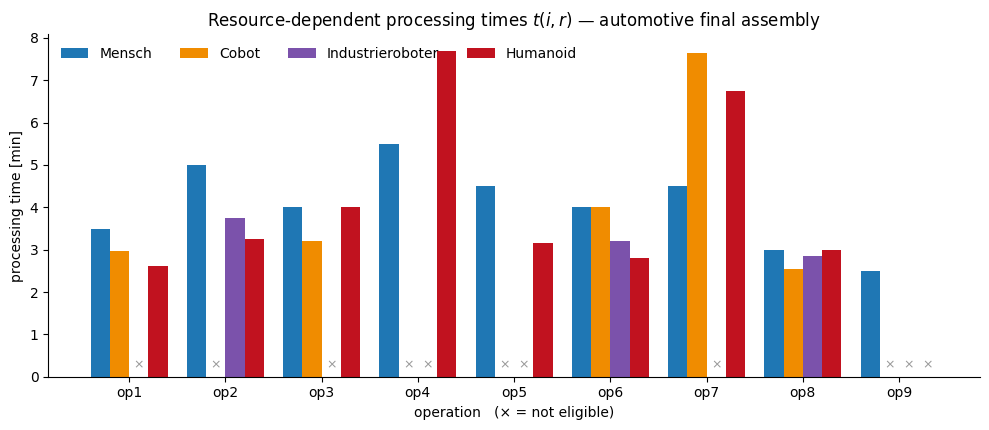

In [20]:
# Visualise the time profile per resource --------------------------------------
col = {"Mensch": "#1f77b4", "Cobot": "#f08c00", "Industrieroboter": "#7b52ab", "Humanoid": "#c1121f"}

fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(N_a); w = 0.2
for r in range(R):
    vals = [t_r[i][r] if elig[i][r] else 0 for i in range(N_a)]
    ax.bar(x + (r - 1.5) * w, vals, w, label=Resources[r], color=col[Resources[r]])
    for i in range(N_a):                       # mark ineligible combinations
        if not elig[i][r]:
            ax.text(x[i] + (r - 1.5) * w, 0.12, "×", ha="center", va="bottom",
                    fontsize=9, color="#999")
ax.set_xticks(x)
ax.set_xticklabels([f"op{i+1}" for i in range(N_a)])
ax.set_xlabel("operation   (× = not eligible)")
ax.set_ylabel("processing time [min]")
ax.set_title("Resource-dependent processing times $t(i,r)$ — automotive final assembly")
ax.legend(frameon=False, ncol=4, loc="upper left")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Cost data & capital budgeting
---
Each resource carries a one-off **investment** plus an hourly **operating** cost; over a planning horizon $H$ the total is $K_r=\text{invest}_r+\text{oper}_r\cdot H$. The figures reflect current German industrial conditions: a fully burdened manufacturing labour cost of ≈ 48 €/h; a cobot cell of 75 k€ whose operating cost carries **one third of a supervising worker** (1 worker : 3 cobots) plus maintenance ≈ 20 €/h; a fenced industrial-robot cell of 120 k€ running almost unattended (≈ 4 €/h); and an industrial humanoid at 200 k€ with ≈ 12 €/h (energy + higher maintenance of many actuators). All values are assumptions the reader can replace.

In [21]:
invest = {"Mensch": 0, "Cobot": 75_000, "Industrieroboter": 120_000, "Humanoid": 200_000}   # [EUR]
oper   = {"Mensch": 48, "Cobot": 20,    "Industrieroboter": 4,       "Humanoid": 12}       # [EUR/h]
H = 2000                                                                                    # [h/year]

def K_of(H):
    """Total cost per resource over the horizon: K(r) = investment + operating * H."""
    return [invest[Resources[r]] + oper[Resources[r]] * H for r in range(R)]

K = K_of(H)
B_min = M_a * min(K)          # cheapest feasible line (all stations on the cheapest resource)
print("K(r) [EUR over horizon]:", {Resources[r]: f"{K[r]:,}" for r in range(R)})
print(f"B_min (all-human line) = {B_min:,} EUR")

K(r) [EUR over horizon]: {'Mensch': '96,000', 'Cobot': '115,000', 'Industrieroboter': '128,000', 'Humanoid': '224,000'}
B_min (all-human line) = 576,000 EUR


### Build & solve the extended model
---
`solve_extended(B, H, allowed)` builds and solves the MILP for a given budget. It is solved in **two stages** (minimise $C$, then minimise cost at optimal $C$) so that every reported configuration is Pareto-efficient. `allowed` optionally restricts the usable resources (e.g. `{0}` = human-only baseline); `H` enters the resource costs for the utilisation analysis at the end.

In [22]:
def solve_extended(B, H=2000, allowed=None, verbose=False):
    """Budget-constrained SALBP-2 on the automotive line with 4 resource types and eligibility."""
    allowed = set(range(R)) if allowed is None else set(allowed)
    Kr = K_of(H)

    mE = gp.Model("MILP_automotive")
    mE.setParam("OutputFlag", 0)
    mE.setParam("MIPgap", 0)

    Y  = mE.addVars(M_a, R, vtype=GRB.BINARY, name="Y")          # station k equipped with r
    Sr = mE.addVars(N_a, M_a, R, vtype=GRB.BINARY, name="S")     # op i at station k using r
    Cb = mE.addVar(lb=0, name="C")                               # cycle time
    totalCost = quicksum(Kr[r] * Y[k, r] for k in range(M_a) for r in range(R))

    # 0) assign every operation exactly once
    mE.addConstrs((quicksum(Sr[i, k, r] for k in range(M_a) for r in range(R)) == 1
                   for i in range(N_a)), name="assignCon")
    # 1) exactly one resource per station
    mE.addConstrs((quicksum(Y[k, r] for r in range(R)) == 1 for k in range(M_a)), name="oneResCon")
    # 2) coupling
    mE.addConstrs((Sr[i, k, r] <= Y[k, r]
                   for i in range(N_a) for k in range(M_a) for r in range(R)), name="couplingCon")
    # 3) eligibility  S(i,k,r) = 0 where resource r cannot do operation i
    mE.addConstrs((Sr[i, k, r] == 0
                   for i in range(N_a) for r in range(R) if not elig[i][r]
                   for k in range(M_a)), name="eligCon")
    # 4) cycle time with resource-dependent times
    mE.addConstrs((quicksum(Sr[i, k, r] * (t_r[i][r] or 0) for i in range(N_a) for r in range(R)) <= Cb
                   for k in range(M_a)), name="cycleTimeCon")
    # 5) precedence relations
    mE.addConstrs((quicksum(Sr[i, k, r] * k for k in range(M_a) for r in range(R)) <=
                   quicksum(Sr[j, k, r] * k for k in range(M_a) for r in range(R))
                   for i in range(N_a) for j in range(N_a) if [i + 1, j + 1] in Prec_a),
                  name="precRelCon")
    # 6) budget
    mE.addConstr(totalCost <= B, name="budgetCon")
    # optional resource restriction
    for r in range(R):
        if r not in allowed:
            mE.addConstrs((Y[k, r] == 0 for k in range(M_a)), name=f"forbidRes{r}")

    # stage 1: minimise cycle time
    mE.setObjective(Cb, GRB.MINIMIZE)
    mE.optimize()
    if mE.status != GRB.OPTIMAL:
        return {"B": B, "status": mE.status, "C": None}
    C_opt = Cb.x

    # stage 2: among all optima, take the cheapest equipment mix
    mE.addConstr(Cb <= C_opt + 1e-6)
    mE.setObjective(totalCost, GRB.MINIMIZE)
    mE.optimize()

    resource_of = {k: next(r for r in range(R) if Y[k, r].x > 0.5) for k in range(M_a)}
    equip  = {k: Resources[resource_of[k]] for k in range(M_a)}
    assign = {k: [i + 1 for i in range(N_a) for r in range(R) if Sr[i, k, r].x > 0.5] for k in range(M_a)}
    counts = [sum(resource_of[k] == r for k in range(M_a)) for r in range(R)]
    cost   = int(sum(Kr[r] * round(Y[k, r].x) for k in range(M_a) for r in range(R)))

    if verbose:
        print(f"Budget B = {B:,} EUR   ->   min. cycle time C = {round(C_opt, 2)}"
              f"   (cheapest mix costs {cost:,} EUR)")
        for k in range(M_a):
            ops  = assign[k]
            load = round(sum(t_r[i - 1][resource_of[k]] for i in ops), 2)
            print(f"  Station {k+1}: {equip[k]:16s} ops {ops}   (load {load})")

    return {"B": B, "status": int(mE.status), "C": round(C_opt, 2),
            "equip": equip, "assign": assign, "resource_of": resource_of,
            "counts": counts, "cost": cost, "nHumanoid": counts[3]}

Solve once for an example budget: with 650 k€ the optimum already deploys a cobot **and** an industrial robot, while the delicate operations (4, 7, 9) stay with humans.

In [23]:
B_example = 650_000
sol = solve_extended(B_example, verbose=True)

Budget B = 650,000 EUR   ->   min. cycle time C = 6.6   (cheapest mix costs 627,000 EUR)
  Station 1: Cobot            ops [1, 3]   (load 6.18)
  Station 2: Industrieroboter ops [2, 8]   (load 6.6)
  Station 3: Mensch           ops [4]   (load 5.5)
  Station 4: Mensch           ops [5]   (load 4.5)
  Station 5: Mensch           ops [7]   (load 4.5)
  Station 6: Mensch           ops [6, 9]   (load 6.5)


### Visualization 1 — resource allocation & station loads
---
Each bar is one station, coloured by its resource; segments are the assigned operations, drawn to scale with their resource-dependent times. The dashed line is the resulting cycle time $C$.

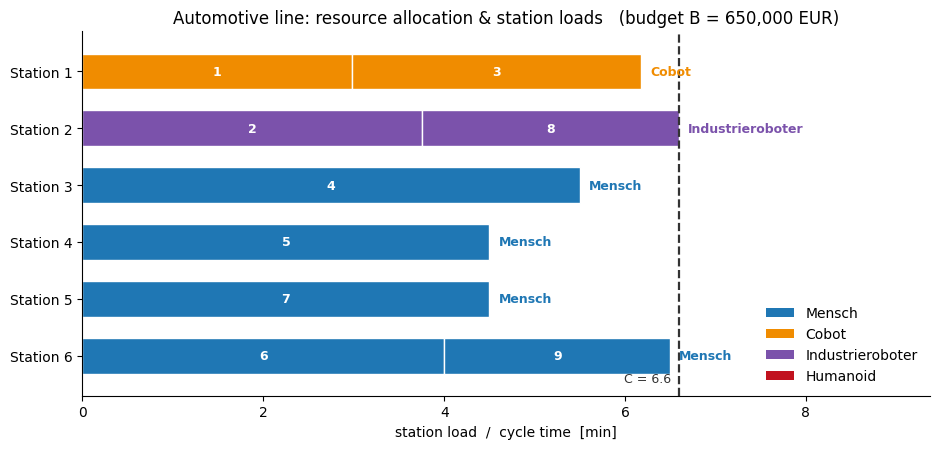

In [24]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for k in range(M_a):
    r = sol["resource_of"][k]
    left = 0
    for op in sol["assign"][k]:
        w = t_r[op - 1][r]
        ax.barh(k, w, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
        ax.text(left + w / 2, k, str(op), ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
        left += w
    ax.text(left + 0.1, k, sol["equip"][k], va="center",
            color=col[Resources[r]], fontsize=9, fontweight="bold")

ax.axvline(sol["C"], ls="--", lw=1.6, color="#333")
ax.set_yticks(range(M_a))
ax.set_yticklabels([f"Station {k+1}" for k in range(M_a)])
ax.set_ylim(-0.7, M_a - 0.3)
ax.invert_yaxis()
ax.text(sol["C"], M_a - 0.6, f"C = {sol['C']}  ", color="#333", fontsize=9, va="center", ha="right")
ax.set_xlim(0, sol["C"] * 1.42)
ax.set_xlabel("station load  /  cycle time  [min]")
ax.set_title(f"Automotive line: resource allocation & station loads   (budget B = {B_example:,} EUR)")
ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
          loc="lower right", frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 2 — the time–cost frontier
---
Sweeping the budget from the all-human line upwards yields the central result: **how much cycle time each euro of budget buys**, and which equipment mix realises it.

In [25]:
budgets  = list(range(B_min, 950_001, 10_000))
frontier = [solve_extended(B) for B in budgets]

df_frontier = pd.DataFrame({
    "Budget B [EUR]":    [f["B"] for f in frontier],
    "min. cycle time C": [f["C"] for f in frontier],
    "mix (M,C,IR,H)":    [tuple(f["counts"]) for f in frontier],
    "mix cost [EUR]":    [f["cost"] for f in frontier],
})
print(df_frontier.iloc[::4].to_string(index=False))

 Budget B [EUR]  min. cycle time C mix (M,C,IR,H)  mix cost [EUR]
         576000               7.50   (6, 0, 0, 0)          576000
         616000               6.95   (5, 0, 1, 0)          608000
         656000               6.60   (4, 1, 1, 0)          627000
         696000               6.60   (4, 1, 1, 0)          627000
         736000               6.18   (4, 1, 0, 1)          723000
         776000               6.18   (4, 1, 0, 1)          723000
         816000               6.18   (4, 1, 0, 1)          723000
         856000               6.18   (4, 1, 0, 1)          723000
         896000               6.18   (4, 1, 0, 1)          723000
         936000               6.18   (4, 1, 0, 1)          723000


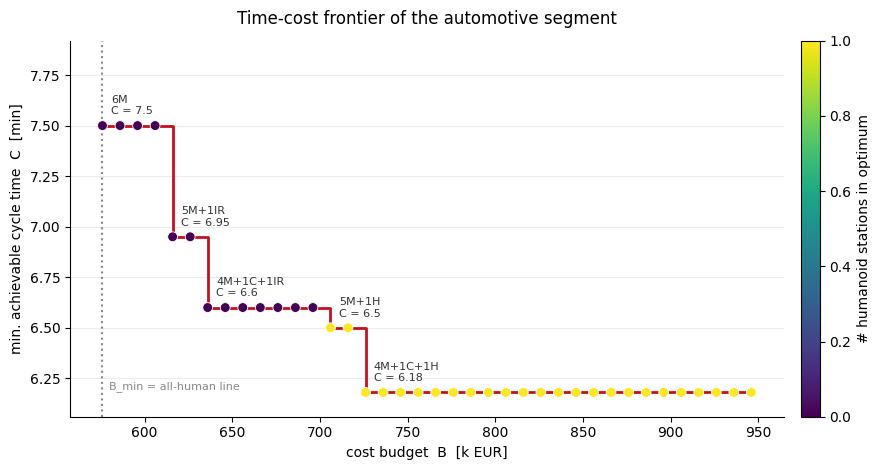

In [26]:
xb = [f["B"] / 1000 for f in frontier]
yc = [f["C"] for f in frontier]
nh = [f["nHumanoid"] for f in frontier]

def mixlabel(cnt):
    return "+".join(f"{n}{s}" for n, s in zip(cnt, ["M", "C", "IR", "H"]) if n > 0)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.step(xb, yc, where="post", color="#c1121f", lw=2, zorder=2)
sc = ax.scatter(xb, yc, c=nh, cmap="viridis", s=50, zorder=3,
                edgecolor="white", linewidth=0.6)
cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("# humanoid stations in optimum")

seen = set()
for f in frontier:                       # annotate each new plateau with its mix
    if f["C"] not in seen:
        seen.add(f["C"])
        ax.annotate(f"{mixlabel(f['counts'])}\nC = {f['C']}",
                    (f["B"] / 1000, f["C"]), textcoords="offset points",
                    xytext=(6, 8), fontsize=8, color="#333")
ax.axvline(B_min / 1000, ls=":", color="#888")
ax.text(B_min / 1000, min(yc), "  B_min = all-human line", color="#888", va="bottom", fontsize=8)
ax.set_ylim(min(yc) - 0.12, max(yc) + 0.42)
ax.set_xlabel("cost budget  B  [k EUR]")
ax.set_ylabel("min. achievable cycle time  C  [min]")
ax.set_title("Time-cost frontier of the automotive segment", pad=12)
ax.grid(axis="y", alpha=0.25)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 3 — marginal value of budget
---
Reading the frontier as an investment decision: the Pareto-efficient "knees" (cheapest mix per cycle time) show what each additional step costs and buys. Note the humanoid's entry step: it is *expensive per minute saved* — but once a humanoid is in the line, completing the mix with a cobot is cheap and effective again. Investments come in lumps, not smooth curves.

               step  from C  to C  dC [min]  extra cost [EUR]  dC per 100k EUR
       6M -> 5M+1IR    7.50  6.95      0.55             32000             1.72
5M+1IR -> 4M+1C+1IR    6.95  6.60      0.35             19000             1.84
 4M+1C+1IR -> 5M+1H    6.60  6.50      0.10             77000             0.13
  5M+1H -> 4M+1C+1H    6.50  6.18      0.32             19000             1.68


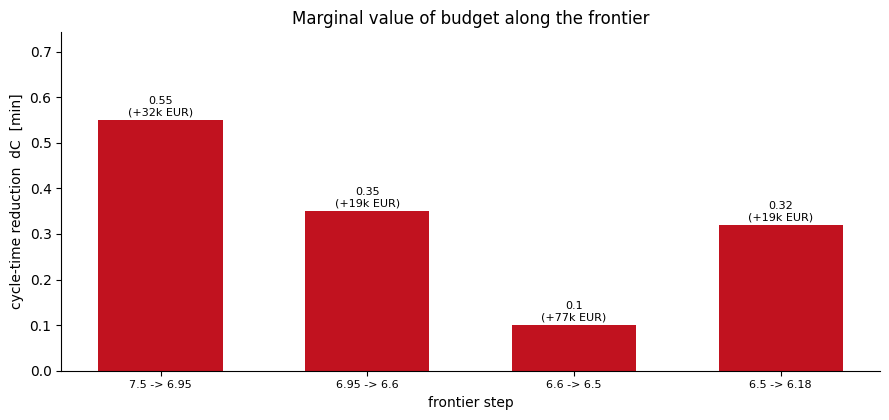

In [27]:
knees = {}
for f in frontier:
    if f["C"] not in knees:
        knees[f["C"]] = f
knees = sorted(knees.values(), key=lambda f: -f["C"])      # slow/cheap -> fast/expensive

rows = []
for a, b in zip(knees[:-1], knees[1:]):
    dC, dE = round(a["C"] - b["C"], 2), b["cost"] - a["cost"]
    rows.append({"step": f"{mixlabel(a['counts'])} -> {mixlabel(b['counts'])}",
                 "from C": a["C"], "to C": b["C"], "dC [min]": dC,
                 "extra cost [EUR]": dE, "dC per 100k EUR": round(dC / (dE / 1e5), 2)})
df_marg = pd.DataFrame(rows)
print(df_marg.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.3))
dCs = [r["dC [min]"] for r in rows]
ax.bar(range(len(rows)), dCs, 0.6, color="#c1121f")
for j, r in enumerate(rows):
    ax.text(j, r["dC [min]"] + 0.006, f"{r['dC [min]']}\n(+{r['extra cost [EUR]']//1000}k EUR)",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels([f"{r['from C']} -> {r['to C']}" for r in rows], fontsize=8)
ax.set_xlabel("frontier step")
ax.set_ylabel("cycle-time reduction  dC  [min]")
ax.set_title("Marginal value of budget along the frontier")
ax.set_ylim(0, max(dCs) * 1.35)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 4 — how the optimal resource mix shifts
---
The same efficient configurations from the equipment side. The pattern is a **substitution story in two acts**: first the *fenced industrial robot* enters (cheap speed on rigid, fixtured tasks), then the *humanoid displaces it* — because at higher budgets the binding stations are the bulky, human-shaped ones (chassis, cockpit, seats) that the fenced robot cannot serve. Humans always keep the delicate operations (4, 7, 9).

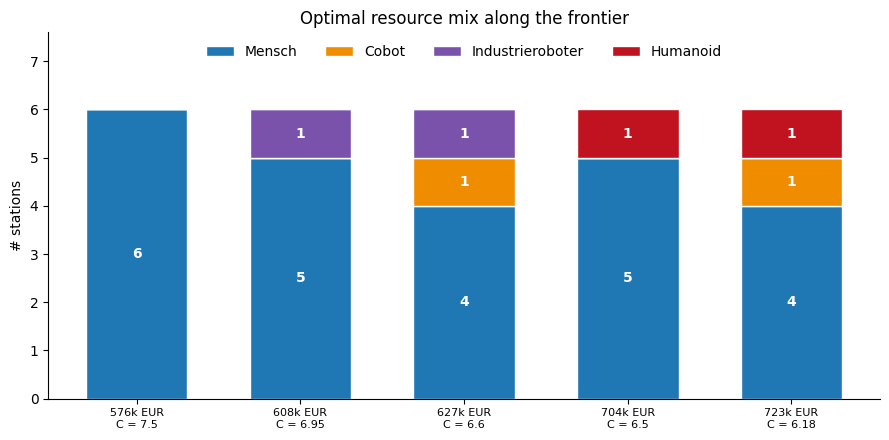

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
xk = np.arange(len(knees)); bottom = np.zeros(len(knees))
for r in range(R):
    vals = [k["counts"][r] for k in knees]
    ax.bar(xk, vals, 0.62, bottom=bottom, label=Resources[r],
           color=col[Resources[r]], edgecolor="white")
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(xk[j], bottom[j] + v / 2, str(v), ha="center", va="center",
                    color="white", fontweight="bold")
    bottom = bottom + vals
ax.set_xticks(xk)
ax.set_xticklabels([f"{k['cost']//1000}k EUR\nC = {k['C']}" for k in knees], fontsize=8)
ax.set_ylabel("# stations")
ax.set_ylim(0, M_a + 1.6)
ax.set_title("Optimal resource mix along the frontier")
ax.legend(frameon=False, ncol=4, loc="upper center")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Visualization 5 — capital-budgeting view: the role of utilisation $H$
---
Because $K_r=\text{invest}_r+\text{oper}_r\cdot H$, the cost ranking of the resources depends on **how intensively the line runs**. Two structural insights: robots overtake the human worker at surprisingly low utilisations (the cobot and the fenced robot already below ≈ 2 700–2 800 h/year, the humanoid at ≈ 5 600 h/year — i.e. from two-shift operation onwards); and the **industrial robot is *always* cheaper than the humanoid** — the humanoid is never bought for cost reasons, but for its *capability* on human-shaped, unfenceable stations. A pure operating-cost budget could not express any of this.

Break-even utilisations H* (equal K over the horizon):
  Mensch           = Cobot            at H* =   2,679 h/year
  Mensch           = Industrieroboter at H* =   2,727 h/year
  Mensch           = Humanoid         at H* =   5,556 h/year
  Cobot            = Industrieroboter at H* =   2,812 h/year
  Cobot            = Humanoid         at H* =  15,625 h/year
  Industrieroboter always cheaper than Humanoid


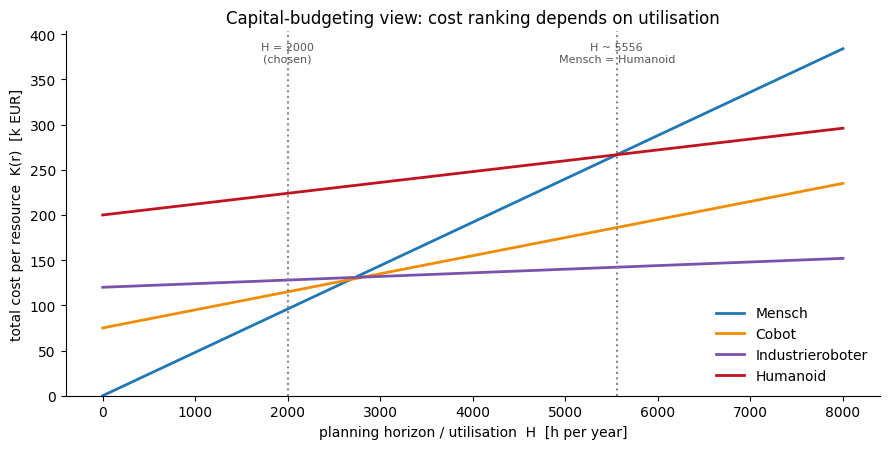

In [29]:
import itertools
print("Break-even utilisations H* (equal K over the horizon):")
for a, b in itertools.combinations(range(R), 2):
    d_inv, d_op = invest[Resources[b]] - invest[Resources[a]], oper[Resources[a]] - oper[Resources[b]]
    if d_op > 0 and d_inv > 0:
        print(f"  {Resources[a]:16s} = {Resources[b]:16s} at H* = {d_inv/d_op:7,.0f} h/year")
    elif d_inv >= 0 and d_op <= 0:
        print(f"  {Resources[a]:16s} always cheaper than {Resources[b]}")

fig, ax = plt.subplots(figsize=(9, 4.6))
Hs = np.linspace(0, 8000, 200)
for r in range(R):
    ax.plot(Hs, [(invest[Resources[r]] + oper[Resources[r]] * h) / 1000 for h in Hs],
            label=Resources[r], color=col[Resources[r]], lw=2)
trans = ax.get_xaxis_transform()
for Hb, txt in [(2000, "H = 2000\n(chosen)"), (200000/36, "H ~ 5556\nMensch = Humanoid")]:
    ax.axvline(Hb, ls=":", color="#888")
    ax.text(Hb, 0.97, txt, transform=trans, fontsize=8, ha="center", va="top", color="#555")
ax.set_xlabel("planning horizon / utilisation  H  [h per year]")
ax.set_ylabel("total cost per resource  K(r)  [k EUR]")
ax.set_title("Capital-budgeting view: cost ranking depends on utilisation")
ax.legend(frameon=False, loc="lower right")
ax.set_ylim(bottom=0)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Reading the results — managerial & academic takeaways
---
- **The frontier has five efficient configurations** for this segment: all-human ($C=7.5$ at 576 k€), + industrial robot ($6.95$, 608 k€), + cobot ($6.6$, 627 k€), humanoid instead of the fenced robot ($6.5$, 704 k€), and the full mix cobot + humanoid ($6.18$, 723 k€) — a 17.6 % cycle-time reduction for +25.5 % budget.
- **Eligibility drives the structure.** The delicate operations (Kabelbaum, Clips, Endkontrolle) are human at *every* budget — automation capital flows to the heavy, rigid, repetitive stations.
- **Two-act substitution.** Cheap speed first (fenced robot on chassis/battery), capability later: the humanoid displaces the fenced robot once the binding stations are the bulky, human-shaped ones (Fahrwerk, Cockpit, Sitze) that fencing cannot reach.
- **The humanoid is never the cheap option** ($K$ always above the fenced robot); it is bought for *where it can work*, not for what it costs per hour. Its entry step is the most expensive minute on the frontier — but it unlocks the best configuration.
- **Utilisation is the hidden lever:** at the chosen $H=2000$ h the human is competitive; from ≈ 2 700 h (cobot, fenced robot) and ≈ 5 600 h (humanoid) the machines dominate on cost — on a three-shift line the frontier tilts sharply toward automation.

**Differentiation from Battaïa et al. (2025).** The humanoid is modelled as its *own* hardware resource with an eligibility profile (not a collaborative mode); cost is split into **investment + operating** over a horizon $H$ (capital budgeting, not an operating-cost cap); the budget is a **hard constraint**, never in the objective; and there is **no scheduling/setup layer** — which keeps the model light enough to trace the full frontier, run the two-stage Pareto refinement, and study utilisation sensitivity.

### Interactive — budget slider driving Visualization 1
---
Drag the **budget slider** to re-solve the model in real time: the chart is *Visualization 1*, redrawn for the chosen budget. Watch the fenced robot enter first, then be displaced by the humanoid as the budget grows — while operations 4, 7 and 9 never leave the humans. *(Requires `ipywidgets`; run the cell, then move the slider. The static image is the preview at B = 650,000 €.)*

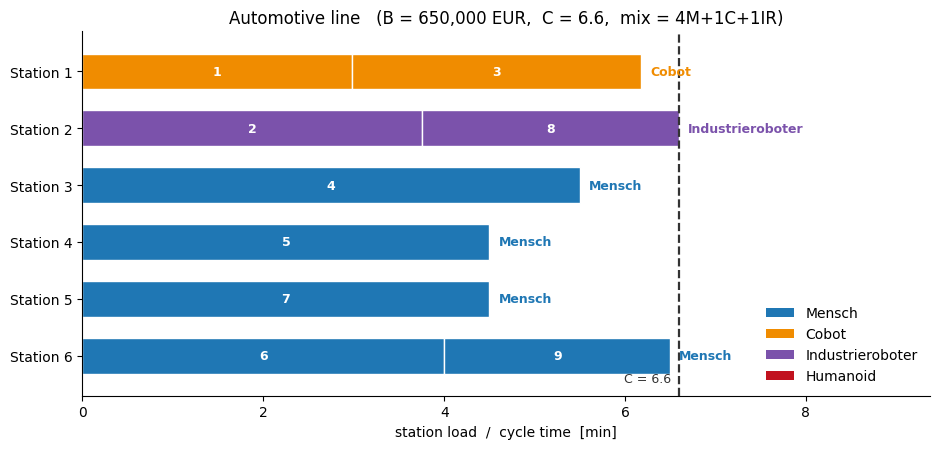

In [30]:
def plot_station_loads(B):
    """Visualization 1, redrawn for an arbitrary budget B."""
    s = solve_extended(int(B))
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    for k in range(M_a):
        r = s["resource_of"][k]
        left = 0
        for op in s["assign"][k]:
            w = t_r[op - 1][r]
            ax.barh(k, w, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
            ax.text(left + w / 2, k, str(op), ha="center", va="center",
                    color="white", fontsize=9, fontweight="bold")
            left += w
        ax.text(left + 0.1, k, s["equip"][k], va="center",
                color=col[Resources[r]], fontsize=9, fontweight="bold")
    ax.axvline(s["C"], ls="--", lw=1.6, color="#333")
    ax.set_yticks(range(M_a)); ax.set_yticklabels([f"Station {k+1}" for k in range(M_a)])
    ax.set_ylim(-0.7, M_a - 0.3); ax.invert_yaxis()
    ax.text(s["C"], M_a - 0.6, f"C = {s['C']}  ", color="#333", fontsize=9, va="center", ha="right")
    ax.set_xlim(0, s["C"] * 1.42)
    ax.set_xlabel("station load  /  cycle time  [min]")
    ax.set_title(f"Automotive line   (B = {int(B):,} EUR,  C = {s['C']},  mix = {mixlabel(s['counts'])})")
    ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
              loc="lower right", frameon=False)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    plt.tight_layout(); plt.show()

# Interactive slider (falls back to a static chart if ipywidgets is unavailable)
try:
    import ipywidgets as widgets
    widgets.interact(
        plot_station_loads,
        B=widgets.IntSlider(value=B_example, min=B_min, max=950_000, step=10_000,
                            description="Budget B [EUR]:", continuous_update=False,
                            readout_format=",d", style={"description_width": "initial"},
                            layout=widgets.Layout(width="640px")))
except ModuleNotFoundError:
    print("ipywidgets not available - showing a static chart instead "
          "(install with: pip install ipywidgets)")
    plot_station_loads(B_example)